# Looks in Excel -> Python
- EXCEL
    - VLOOKUP - Searches Vertically
    - HLOOKUP - Searches Horizontally
    - XLOOKUP - Searches Any Direction
    - MATCH - returns the position / index of value
- PYTHON
    - map() - Eq to XLOOKUP
    - merge() - Eq to XLOOKUP for multiple columns

In [1]:
import pandas as pd
import numpy as np

In [3]:
employees = pd.read_clipboard('\t')
employees

,ser,empID,Name,DeptID
0,1,101,Amit,D01
1,2,102,Ravi,D02
2,3,103,Priya,D01
3,4,104,Neha,D03
4,4,105,Dhiraj,D05


In [4]:
empScript = employees.to_dict(orient='list')
empScript

{'ser': [1, 2, 3, 4, 4],
 'empID': [101, 102, 103, 104, 105],
 'Name': ['Amit', 'Ravi', 'Priya', 'Neha', 'Dhiraj'],
 'DeptID': ['D01', 'D02', 'D01', 'D03', 'D05']}

In [5]:
emp2 = pd.DataFrame(empScript)
emp2

,ser,empID,Name,DeptID
0,1,101,Amit,D01
1,2,102,Ravi,D02
2,3,103,Priya,D01
3,4,104,Neha,D03
4,4,105,Dhiraj,D05


### Match
- 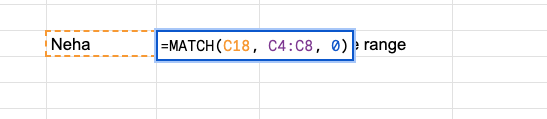

In [41]:
## Match in Excel
emp2.index[emp2["Name"] == "Neha"][0]
# np.int64(3): 3 +1 : 4th position

np.int64(3)

In [42]:
emp2.index[emp2["Name"] == "Amit"][0]  # 0+1 Position

np.int64(0)

In [43]:
np.where(emp2["Name"] == "Neha")[0][0] + 1 #4th positon

np.int64(4)

## Department Table

In [11]:
departments = pd.read_clipboard('\t')
departments

,Head,DeptID,Department,Location
0,Rosul,D02,HR,New York
1,Rita,D01,Finance,California
2,Kunal,D03,IT,New Jersey


In [12]:
deptScript = departments.to_dict(orient='list')
deptScript

{'Head': ['Rosul', 'Rita', 'Kunal'],
 'DeptID': ['D02', 'D01', 'D03'],
 'Department': ['HR', 'Finance', 'IT'],
 'Location': ['New York', 'California', 'New Jersey']}

In [13]:
dept = pd.DataFrame(deptScript)
dept

,Head,DeptID,Department,Location
0,Rosul,D02,HR,New York
1,Rita,D01,Finance,California
2,Kunal,D03,IT,New Jersey


## EXCEL
- =XLOOKUP(D4,$C$13:$C$15,$D$13:$E$15,"NotFound",1)
- =XLOOKUP(D4,$C$13:$C$15,$B$13:$B$15,"NotFound",1)
- =vlookup(D4,$C$13:$E$15,2,FALSE)
- =iferror(vlookup(D4,$C$13:$E$15,2,FALSE),"NA")
- 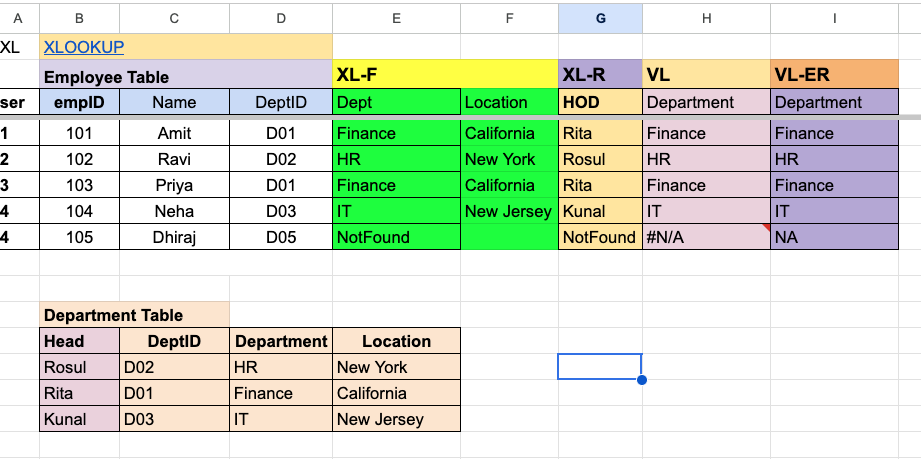

## Python
## Method-1 : map
- merge_asof() - approx
    - pd.merge_asof(df1, df2, on="Dept_ID", direction="backward") 

In [17]:
lookup = departments.set_index("DeptID")["Department"]
lookup

DeptID
D02         HR
D01    Finance
D03         IT
Name: Department, dtype: object

In [23]:
employees['Dept_Map'] = employees["DeptID"].map(lookup).fillna("Not Found")
employees

,ser,empID,Name,DeptID,Dept_Map
0,1,101,Amit,D01,Finance
1,2,102,Ravi,D02,HR
2,3,103,Priya,D01,Finance
3,4,104,Neha,D03,IT
4,4,105,Dhiraj,D05,Not Found


In [ ]:
### Merge
- this will serve VLookup, XLookup 

In [24]:
### merge
employees2  = employees.merge(departments, on="DeptID", how="left").fillna("NotAvailable")
employees2

,ser,empID,Name,DeptID,Dept_Map,Head,Department,Location
0,1,101,Amit,D01,Finance,Rita,Finance,California
1,2,102,Ravi,D02,HR,Rosul,HR,New York
2,3,103,Priya,D01,Finance,Rita,Finance,California
3,4,104,Neha,D03,IT,Kunal,IT,New Jersey
4,4,105,Dhiraj,D05,Not Found,NotAvailable,NotAvailable,NotAvailable


## HLOOKUP


In [27]:
employees

,ser,empID,Name,DeptID,Dept_Map
0,1,101,Amit,D01,Finance
1,2,102,Ravi,D02,HR
2,3,103,Priya,D01,Finance
3,4,104,Neha,D03,IT
4,4,105,Dhiraj,D05,Not Found


In [29]:
empT = employees.T
empT

,0,1,2,3,4
ser,1,2,3,4,4
empID,101,102,103,104,105
Name,Amit,Ravi,Priya,Neha,Dhiraj
DeptID,D01,D02,D01,D03,D05
Dept_Map,Finance,HR,Finance,IT,Not Found


In [30]:
empT.columns = empT.iloc[0]
empT

ser,1,2,3,4,4
ser,1,2,3,4,4
empID,101,102,103,104,105
Name,Amit,Ravi,Priya,Neha,Dhiraj
DeptID,D01,D02,D01,D03,D05
Dept_Map,Finance,HR,Finance,IT,Not Found


In [31]:
# remove 1st row
empT = empT.iloc[1:]
empT

ser,1,2,3,4,4
empID,101,102,103,104,105
Name,Amit,Ravi,Priya,Neha,Dhiraj
DeptID,D01,D02,D01,D03,D05
Dept_Map,Finance,HR,Finance,IT,Not Found


In [34]:
empT.loc[:, empT.loc["empID"] == 104]
#department of Neha

ser,4
empID,104
Name,Neha
DeptID,D03
Dept_Map,IT


In [35]:
empT.loc["Dept_Map", empT.loc["empID"] == 104].iloc[0]

'IT'